In [1478]:
# !pip install "numpy" --force-reinstall
# !pip3 install tensorflow --upgrade


import tensorflow as tf
import tensorflow_decision_forests as tfdf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [1479]:
train_data = pd.read_csv("train.csv")
train_data.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [1480]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [1481]:
train_data.describe(
)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [1482]:
train_data.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [1483]:
# women = train_data.loc[train_data.AgeBand ==0]["Survived"]
# rate_women = sum(women)/len(women)

# # print("% of women who survived:", rate_women)

In [1484]:
men = train_data.loc[train_data.Sex == 'male']["Survived"]
rate_men = sum(men)/len(men)

print("% of men who survived:", rate_men)

% of men who survived: 0.18890814558058924


In [1485]:
train_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [1486]:
train_data.drop(['PassengerId','Name','Cabin','Ticket'],axis=1,inplace=True)

In [1487]:
# train_data['Age'] = train_data.groupby(['Sex'])['Age'].transform(lambda x: x.fillna(x.mean()))
train_data['Age'] = train_data['Age'].interpolate()


In [1488]:
train_data['Embarked'].value_counts()


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [1489]:
missing = train_data[train_data['Embarked'].isna()]
print (missing)


     Survived  Pclass     Sex   Age  SibSp  Parch  Fare Embarked
61          1       1  female  38.0      0      0  80.0      NaN
829         1       1  female  62.0      0      0  80.0      NaN


In [1490]:
for i, row in train_data[train_data['Embarked'].isna()].iterrows():
    similar = train_data[
        (train_data['Embarked'].notna()) &
        (train_data['Sex'] == row['Sex']) &
        (abs(train_data['Age'] - row['Age']) < 2)
    ]
    if not similar.empty:
        most_common = similar['Embarked'].value_counts().idxmax()
        train_data.at[i, 'Embarked'] = most_common


print(similar)

     Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
275         1       1  female  63.0      1      0  77.9583        S
483         1       3  female  63.0      0      0   9.5875        S


In [1491]:
# candidates = train_data[train_data['Embarked'].notna()]
# similar = candidates[
#     (candidates['Sex'].isin(missing['Sex'])) &
#     (abs(candidates['Age'] - missing['Age'].values[0]) < 2)
# ]


In [1492]:
train_data.head(5)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [1493]:
print("TensorFlow v" + tf.__version__)
print("TensorFlow Decision Forests v" + tfdf.__version__)

TensorFlow v2.19.0
TensorFlow Decision Forests v1.12.0


<Axes: xlabel='Survived'>

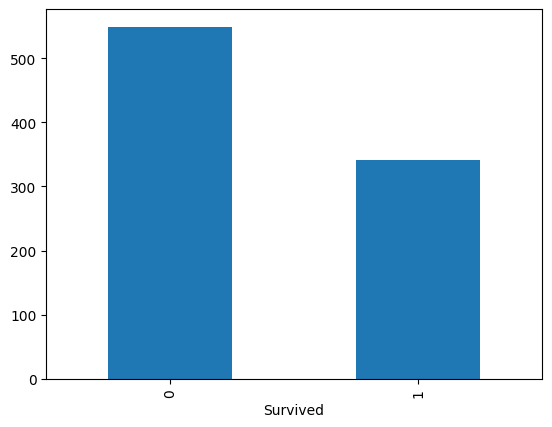

In [1494]:
plot_df = train_data.Survived.value_counts()
plot_df.plot(kind="bar")

In [1495]:
train_data['Pclass*Age'] = train_data['Pclass'] * train_data['Age']

In [1496]:
train_data['Sex01'] = train_data['Sex'].map({'male': 0, 'female': 1})
train_data['Sex/Fare'] = train_data['Sex01']/train_data['Fare']

In [1497]:
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1


In [1498]:
train_data['IsAlone'] = (train_data['FamilySize'] == 1).astype(int)


In [1499]:
train_data['AgeBand'] = pd.cut(train_data['Age'], bins=[0, 8, 12, 18, 25, 40,65,80,100], labels=[0,1,2,3,4,5,6,7])
# train_data.drop(['Age'],axis=1,inplace=True)


In [1500]:
def split_dataset(dataset, test_ratio=0.20):
  test_indices = np.random.rand(len(dataset)) < test_ratio
  return dataset[~test_indices], dataset[test_indices]

train_ds_pd, valid_ds_pd = split_dataset(train_data)
print("{} examples in training, {} examples in testing.".format(
    len(train_ds_pd), len(valid_ds_pd)))

702 examples in training, 189 examples in testing.


In [1501]:
label = "Survived"

In [1502]:
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_ds_pd, label=label)
valid_ds = tfdf.keras.pd_dataframe_to_tf_dataset(valid_ds_pd, label=label)

In [1503]:
tfdf.keras.get_all_models()

[tensorflow_decision_forests.keras.RandomForestModel,
 tensorflow_decision_forests.keras.GradientBoostedTreesModel,
 tensorflow_decision_forests.keras.CartModel,
 tensorflow_decision_forests.keras.DistributedGradientBoostedTreesModel]

In [1504]:
rf = tfdf.keras.GradientBoostedTreesModel(
    num_trees=500,
    max_depth=5,
    task=tfdf.keras.Task.CLASSIFICATION,
    # growing_strategy="BEST_FIRST_GLOBAL"
    
    # subsample=0.5,
    l2_regularization=0.4,
    # early_stopping="loss-guided"
)
rf.compile(metrics=["accuracy"]) # Optional, you can use this to include a list of eval metrics

Use /tmp/tmpp5hy18z3 as temporary training directory


W0000 00:00:1751789260.841511  114747 gradient_boosted_trees.cc:1873] "goss_alpha" set but "sampling_method" not equal to "GOSS".
W0000 00:00:1751789260.841571  114747 gradient_boosted_trees.cc:1883] "goss_beta" set but "sampling_method" not equal to "GOSS".
W0000 00:00:1751789260.841585  114747 gradient_boosted_trees.cc:1897] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


In [1505]:
rf.fit(x=train_ds)


Reading training dataset...
Training dataset read in 0:00:00.270544. Found 702 examples.
Training model...
Model trained in 0:00:00.164727
Compiling model...


I0000 00:00:1751789261.138532  114747 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1751789261.138575  114747 kernel.cc:783] Collect training examples
I0000 00:00:1751789261.138594  114747 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: CATEGORICAL
  categorial {
    min_vocab_frequency: 0
    max_vocab_count: -1
  }
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1751789261.138748  114747 kernel.cc:401] Number of batches: 1
I0000 00:00:1751789261.138762  114747 kernel.cc:402] Number of examples: 702
I0000 00:00:1751789261.139053  114747 kernel.cc:802] Training dataset:
Number of records: 702
Number of columns: 14

Number of columns by type:
	NUMERICAL: 11 (78.5714%)
	CATEGORICAL: 3 (21.4286%)

Columns:

NUMERICAL: 11 (78.5714%)
	0: "Age" NUMERICAL mean:29.

Model compiled.


In [1506]:
tfdf.model_plotter.plot_model_in_colab(rf, tree_idx=0, max_depth=3)

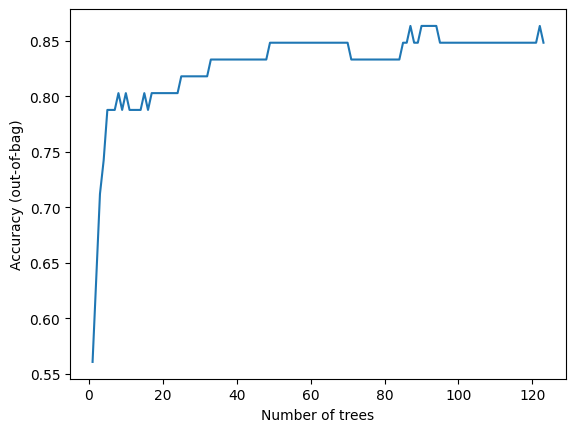

In [1507]:
import matplotlib.pyplot as plt
logs = rf.make_inspector().training_logs()
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.show()

In [1508]:
test_df = pd.read_csv('test.csv')
submission_id = test_df.PassengerId

In [1509]:
test_df.isnull().sum().sort_values(ascending=False)

Cabin          327
Age             86
Fare             1
Name             0
Pclass           0
PassengerId      0
Sex              0
Parch            0
SibSp            0
Ticket           0
Embarked         0
dtype: int64

In [1510]:
test_df['Age'] = test_df['Age'].interpolate()
test_df['Fare'] = test_df['Fare'].interpolate()

In [1511]:
test_df.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


In [1512]:
train_data.head(2)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Pclass*Age,Sex01,Sex/Fare,FamilySize,IsAlone,AgeBand
0,0,3,male,22.0,1,0,7.2500,S,66.0,0,0.000000,2,0,3
1,1,1,female,38.0,1,0,71.2833,C,38.0,1,0.014029,2,0,4


In [1513]:
test_df.drop(['PassengerId','Name','Cabin','Ticket'],axis=1,inplace=True)

In [1514]:
test_df['AgeBand'] = pd.cut(test_df['Age'], bins=[0, 8, 12, 18, 25, 40,65,80,100], labels=[0,1,2,3,4,5,6,7])
# test_df['AgeBand'] = pd.cut(test_df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=[0,1,2,3,4])

In [1515]:
test_df['Sex01'] = test_df['Sex'].map({'male': 0, 'female': 1})

In [1516]:
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1


In [1517]:
test_df['IsAlone'] = (test_df['FamilySize'] == 1).astype(int)
test_df['Age'] = test_df['Age'].interpolate()
test_df['Pclass*Age'] = test_df['Pclass'] *test_df['Age']

In [1518]:

test_df['Sex/Fare'] = test_df['Sex01']/test_df['Fare']
# test_df.drop(['Age'],axis=1,inplace=True)


In [1519]:
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(test_df)

# Get the predictions for testdata
predictions = rf.predict(test_ds)
n_predictions = (predictions > 0.4).astype(int)
output = pd.DataFrame({'PassengerId': submission_id,
                       'Survived': n_predictions.squeeze()})

output.head(2)

1/1 [==============================] - 0s 57ms/step


,PassengerId,Survived
0,892,0
1,893,1


In [1520]:
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
